# Simultaneous transient fitting: the PRBS experiment as one collocation NLP

Notebook `10_prbs_fitting.ipynb` fits rate constants to a transient PRBS experiment with the **shooting** pattern: a stiff implicit-Radau integration per input segment inside `pounce.curve_fit`. That works, but every residual evaluation re-integrates the whole experiment and the optimizer sees the model only through those integrations.

`mk.fit_kinetics_transient` packages the **all-at-once** alternative (issue [#4](https://github.com/jkitchin/discopt-mkm/issues/4)): each run's coverage ODEs are transcribed to orthogonal-collocation constraints (`discopt.dae`) with element boundaries aligned to the input switch times, the fitted constants become discopt Variables shared across runs, and a single weighted least-squares NLP solves for the constants *and* the coverage trajectories simultaneously, with exact automatic-differentiation derivatives. Confidence intervals use the full trajectory sensitivity `dr/du = ∂r/∂u + (∂r/∂x)(dx/du)` (implicit function theorem on the collocation system), so a constant that acts on the response only through the dynamics — here the CO adsorption pre-exponential — still gets a meaningful interval.

This notebook repeats the PRBS exercise with the packaged API and compares against the shooting fit on the same data.

In [1]:
import time
import numpy as np, matplotlib.pyplot as plt
import pounce
import discopt.mkm as mk
from discopt.mkm import numeric

## Mechanism

Same CO oxidation model as notebook 10. The two fitted constants are the CO-adsorption pre-exponential `A_ads` (true value 30) and the surface-reaction pre-exponential `A_surf` (true value $10^8$); at a single temperature only the rate constants $k = A e^{-E_a/RT}$ are identifiable, so the barriers stay fixed.

In [2]:
def build(A_ads=30.0, A_surf=1e8):
    """CO oxidation with the two constants to be estimated as arguments."""
    m = mk.Model('co_ox', T=500.0, R=8.617e-5)
    s = m.site('*', density=1.0)
    CO, O2, CO2 = m.gas('CO'), m.gas('O2'), m.gas('CO2')
    COs, Os = m.adsorbate('CO*', site=s), m.adsorbate('O*', site=s)
    m.step(CO + s >> COs, A=A_ads, Ea=0.0)
    m.step(O2 + 2*s >> 2*Os, A=30.0, Ea=0.0)
    m.step(COs + Os >> CO2 + 2*s, A=A_surf, Ea=0.7)
    return m, (CO, O2, CO2, COs, Os)

## Independent PRBS inputs, irregular sample times, exact-time reference data

The CO and O$_2$ feeds are independent pseudo-random binary sequences with different bit periods, and the CO$_2$ rate is sampled at irregular times — the same experiment class as notebook 10, with a shorter sequence (see the caveats at the end for why the number of input *switches* is the size driver of the collocation NLP).

One data-generation detail matters more than it looks: the reference response is evaluated **at the exact sample times** (the integrator is told to step to them), not interpolated from a coarse trajectory. Linear interpolation of a curving transient biases the "measurements" by several percent right after each switch; a fit whose model evaluates exactly (the collocation NLP does) would then faithfully converge to the *biased* data, while a shooting fit whose model function commits the same interpolation hides the bias by construction.

In [3]:
def prbs(tend, tbit, lo, hi, seed):
    """Pseudo-random binary sequence: values[i] is held on [edges[i], edges[i+1])."""
    r = np.random.default_rng(seed); n = int(np.ceil(tend/tbit))
    return np.arange(n+1)*tbit, np.where(r.integers(0, 2, n), hi, lo).astype(float)

TEND = 1.0
eCO, vCO = prbs(TEND, 0.20, 0.5, 1.5, 1)   # CO:  bit period 0.20
eO2, vO2 = prbs(TEND, 0.26, 0.3, 0.7, 2)   # O2:  bit period 0.26 (unaligned)

# piecewise-constant segments on the union of both switch grids (for the reference integration)
breaks = np.unique(np.r_[eCO, eO2, 0, TEND]); breaks = breaks[(breaks >= 0) & (breaks <= TEND + 1e-9)]
segs = [(breaks[i], breaks[i+1]) for i in range(len(breaks)-1)]
val = lambda e, v, t: v[min(max(np.searchsorted(e, t, 'right')-1, 0), len(v)-1)]
segCO = [float(val(eCO, vCO, (a+b)/2)) for a, b in segs]
segO2 = [float(val(eO2, vO2, (a+b)/2)) for a, b in segs]

rng = np.random.default_rng(7)
t_meas = np.sort(rng.uniform(0.01, TEND, 60))    # irregular sample times

def simulate(A_ads, A_surf, t_out):
    """Reference CO2 rate at exactly t_out: implicit-Radau integration per segment,
    with the sample times inside each segment passed as integrator output points."""
    m, (CO, O2, CO2, COs, Os) = build(A_ads, A_surf); site = m.sites[0]
    out = np.empty_like(t_out); theta = {COs: 0.0, Os: 0.0}
    for (a, b), Pco, Po2 in zip(segs, segCO, segO2):
        conc = {CO: Pco, O2: Po2, CO2: 0.0}
        inside = (t_out >= a) & (t_out < b) | ((b == segs[-1][1]) & (t_out == b))
        t_eval = np.unique(np.r_[a, t_out[inside], b])
        sol = numeric.integrate_coverages(m, conc, 500.0, t_eval, theta0=theta)
        for k, tk in enumerate(sol.t):
            for i in np.where(inside & np.isclose(t_out, tk))[0]:
                th = {COs: sol.y[0, k], Os: sol.y[1, k]}; free = {site: 1 - th[COs] - th[Os]}
                out[i] = numeric.turnover_frequency(m, CO2, th, free, conc, 500.0)
        theta = {COs: sol.y[0, -1], Os: sol.y[1, -1]}
    return out

r_true = simulate(30.0, 1e8, t_meas)
noise = 0.03 * r_true.std()
data = r_true + rng.normal(0, noise, r_true.shape)
print(f'{len(segs)} input segments, {len(t_meas)} samples, noise sigma = {noise:.4f}')

8 input segments, 60 samples, noise sigma = 0.0038


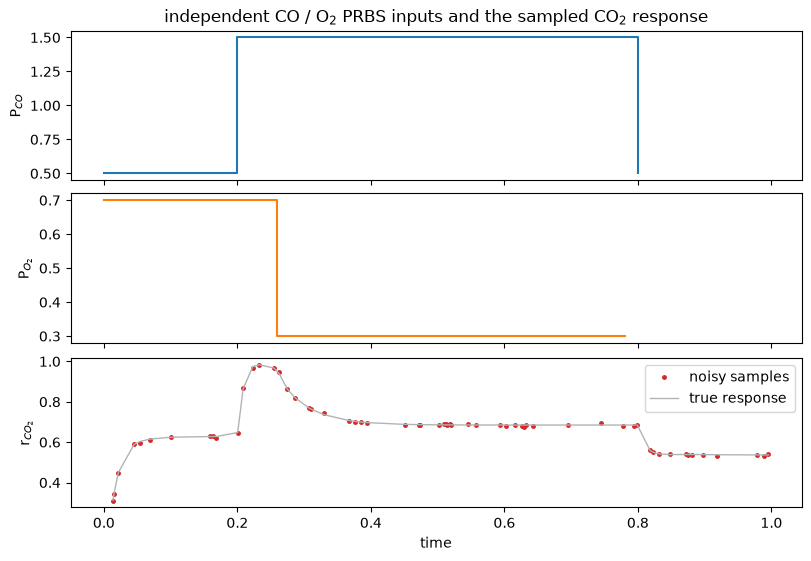

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(8, 5.5), sharex=True, layout='constrained')
ax[0].step(eCO[:-1], vCO, where='post', color='C0'); ax[0].set_ylabel('P$_{CO}$')
ax[1].step(eO2[:-1], vO2, where='post', color='C1'); ax[1].set_ylabel('P$_{O_2}$')
ax[2].plot(t_meas, data, '.', ms=5, color='C3', label='noisy samples')
ax[2].plot(t_meas, r_true, '-', color='0.7', lw=1, label='true response')
ax[2].set_ylabel('r$_{CO_2}$'); ax[2].set_xlabel('time'); ax[2].legend(loc='upper right')
ax[0].set_title('independent CO / O$_2$ PRBS inputs and the sampled CO$_2$ response');

## The simultaneous fit

One `TransientRun` describes the whole experiment: the measured response species, the time series, and the piecewise-constant inputs as `(switch times, values)` pairs — `fit_kinetics_transient` aligns the collocation element boundaries to every switch automatically. `FitParam` is the same object the steady-state `fit_kinetics` uses; pre-exponentials are fit in log space by default and reported back in physical units.

In [5]:
m, (CO, O2, CO2, COs, Os) = build()          # nominal model; FitParam overrides the fitted constants
run = mk.TransientRun(
    response=CO2, t=t_meas, y=data, T=500.0,
    pressures={CO: (eCO, vCO), O2: (eO2, vO2), CO2: 0.0},
    sigma=noise, t_span=(0.0, TEND),
)
fit = [
    mk.FitParam(m.reactions[0], "A", lb=1.0, ub=1e4,  init=10.0, name="A_ads"),
    mk.FitParam(m.reactions[2], "A", lb=1e6, ub=1e10, init=2e7,  name="A_surf"),
]

t0 = time.time()
res = mk.fit_kinetics_transient(m, [run], fit, nfe=20)
t_simultaneous = time.time() - t0
print(f'simultaneous fit: {t_simultaneous:.1f} s')
print(res)
print('true   :  A_ads = 30,  A_surf = 1e8')
print('parameter correlation:'); print(np.round(res.raw.correlation_matrix, 3))

simultaneous fit: 12.5 s
MKMEstimationResult:
  A_ads = 30.3299  (95% CI [29.85, 30.82])
  A_surf = 9.99683e+07  (95% CI [9.98e+07, 1.001e+08])
  objective=62.5489, n_obs=60
true   :  A_ads = 30,  A_surf = 1e8
parameter correlation:
[[ 1.    -0.284]
 [-0.284  1.   ]]


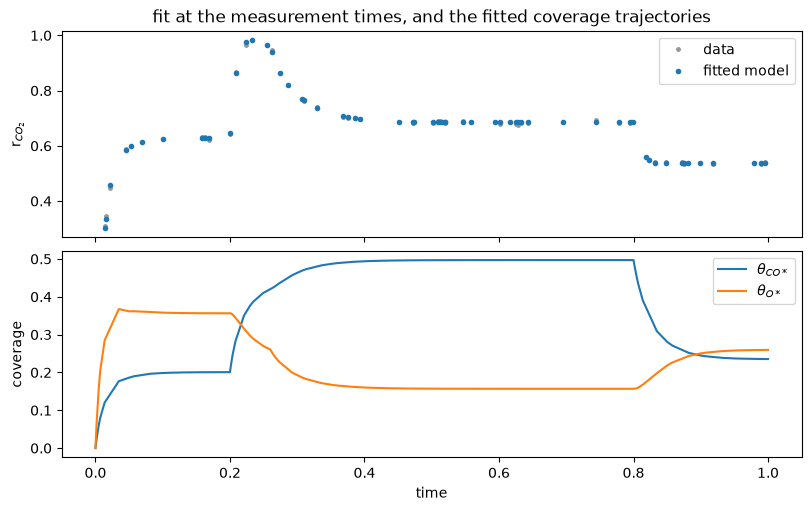

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True, layout='constrained')
ax[0].plot(t_meas, data, '.', ms=5, color='0.6', label='data')
ax[0].plot(t_meas, res.predictions['run0'], 'o', ms=3, color='C0', label='fitted model')
ax[0].set_ylabel('r$_{CO_2}$'); ax[0].legend(loc='upper right')
ax[0].set_title('fit at the measurement times, and the fitted coverage trajectories')
tt = res.times['run0']
ax[1].plot(tt, res.trajectories['run0']['CO*'], '-', label=r'$\theta_{CO*}$')
ax[1].plot(tt, res.trajectories['run0']['O*'], '-', label=r'$\theta_{O*}$')
ax[1].set_xlabel('time'); ax[1].set_ylabel('coverage'); ax[1].legend(loc='upper right');

## The shooting fit on the same data

For a fair comparison the `curve_fit` model function evaluates at the exact sample times too (same `simulate` as the data generation, at the trial constants).

In [7]:
def model(x, logA_ads, logA_surf):
    return simulate(10**logA_ads, 10**logA_surf, t_meas)

t0 = time.time()
cf = pounce.curve_fit(model, np.arange(len(data)), data, p0=[1.0, 7.3])
t_shooting = time.time() - t0
A_ads_sh, A_surf_sh = 10**cf.popt[0], 10**cf.popt[1]
print(f'shooting fit: {t_shooting:.1f} s')
print(f'  A_ads  = {A_ads_sh:.4g}   A_surf = {A_surf_sh:.4g}   R^2 = {cf.r_squared:.4f}')
print(f'  log10-parameter 95% CIs: {np.round(np.asarray(cf.ci), 3).tolist()}')
print()
print(f'{"":14s}{"simultaneous":>16s}{"shooting":>12s}{"true":>8s}')
print(f'{"A_ads":14s}{res.parameters["A_ads"]:16.4g}{A_ads_sh:12.4g}{30:8g}')
print(f'{"A_surf":14s}{res.parameters["A_surf"]:16.4g}{A_surf_sh:12.4g}{1e8:8.0e}')
print(f'{"wall time (s)":14s}{t_simultaneous:16.1f}{t_shooting:12.1f}')

/Users/jkitchin/Dropbox/projects/discopt-mkm/.venv/lib/python3.13/site-packages/pounce/_curve_fit.py:924: UserWarning: pounce.curve_fit: using a finite-difference Jacobian (model is not JAX-traceable and no analytic jac given). Pass jac=<callable> or write the model with jax.numpy for exact derivatives; covariance and sensitivity are most accurate then.
  prob = _build_fit_problem(


shooting fit: 10.6 s
  A_ads  = 29.77   A_surf = 9.996e+07   R^2 = 0.9994
  log10-parameter 95% CIs: [[1.468, 1.48], [7.999, 8.0]]

                  simultaneous    shooting    true
A_ads                    30.33       29.77      30
A_surf               9.997e+07   9.996e+07   1e+08
wall time (s)             12.5        10.6


## Takeaways

- **One call, one NLP.** `TransientRun` + `FitParam` + `fit_kinetics_transient` replaces the hand-rolled integrate-inside-`curve_fit` loop of notebook 10. Both estimators recover the constants; the simultaneous fit reports 95% confidence intervals in physical units from the Fisher information with the **full trajectory sensitivity** — `A_ads` never appears in the CO$_2$ rate expression, so its sensitivity flows entirely through the coverage dynamics and is recovered by the implicit function theorem on the collocation system.
- **Irregular sampling is free.** The model response is interpolated to the exact measurement times with the element's collocation polynomial; nothing needs to align with the mesh.
- **Multi-run fits share constants.** Passing several `TransientRun`s (e.g. at different temperatures) fits one shared `A`/`Ea` set across all runs, Arrhenius-consistently — the multi-temperature analog of notebook 12 in a single call.
- **Caveat: input switches set the problem size.** Every switch time is a mandatory element boundary (plus a geometrically graded first element after each switch to absorb the fast coverage relaxation a step excites). A long PRBS train like notebook 10's full 33-switch sequence transcribes to ~120 elements, and with discopt's current whole-array Hessian-sparsity granularity for vectorized DAE constraints that NLP takes minutes rather than seconds. Keep individual runs to a modest number of switches (or split a long sequence into several runs that share the fitted constants) until that upstream limitation is lifted.
- **Caveat: generate reference data at the sample times.** Interpolating a coarsely saved trajectory onto the sample times biases the data in the fast post-switch transients; the collocation fit is accurate enough to *resolve* that bias (it converges to the interpolated data, not the true dynamics), which is how it was found.